## Setup

In [11]:
import re
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

# Estilo acadêmico
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'font.size': 10,
    'figure.dpi': 300,
    'savefig.dpi': 300,
    'lines.linewidth': 1.5,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'legend.fontsize': 9,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

ROOT = Path('.').resolve()
TESTCASE = 't06-ecn-sender-ect1-prague-dualpi2-ecn2'
CLIENT_LOG = ROOT / 'experiments' / TESTCASE / 'esp_client.log'
SERVER_LOG = ROOT / 'experiments' / TESTCASE / 'server.log'
OUTPUT_DIR = ROOT / 'experiments' / TESTCASE

# Criar diretório de saída se não existir
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Working directory: {ROOT}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Client log: {CLIENT_LOG.exists()}")
print(f"Server log: {SERVER_LOG.exists()}")

Working directory: /Users/juscelioreis/Documents/code/master-l4s-iot/esp32-udp-prague
Output directory: /Users/juscelioreis/Documents/code/master-l4s-iot/esp32-udp-prague/experiments/t06-ecn-sender-ect1-prague-dualpi2-ecn2
Client log: True
Server log: True


## Parsing Cliente

In [12]:
def load_client_log(path=CLIENT_LOG):
    """Parse CSTATS format: CSTATS;t_ms;packets_sent;packets_received;inflight;rtt_us;jitter_us;packet_window;packet_burst;pacing_rate_bps
    Note: RTT and Jitter are in microseconds (us), converted to milliseconds (ms)"""
    rows = []
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line.startswith('CSTATS;'):
                continue
            parts = line.split(';')
            if len(parts) != 10:
                continue
            try:
                rows.append({
                    't_ms': int(parts[1]),
                    'packets_sent': int(parts[2]),
                    'packets_received': int(parts[3]),
                    'inflight': int(parts[4]),
                    'rtt_ms': float(parts[5]) / 1000.0,  # Convert microseconds to milliseconds
                    'jitter_ms': float(parts[6]) / 1000.0,  # Convert microseconds to milliseconds
                    'packet_window': int(parts[7]),
                    'packet_burst': int(parts[8]),
                    'pacing_rate_bps': float(parts[9]),
                })
            except (ValueError, IndexError):
                continue
    
    df = pd.DataFrame(rows)
    if not df.empty:
        df['t_client_s'] = df['t_ms'] / 1000.0
        df = df.sort_values('t_client_s').reset_index(drop=True)
        print(f"\n✓ Cliente: {len(df)} amostras")
        print(f"  Tempo: [{df['t_client_s'].min():.3f}, {df['t_client_s'].max():.3f}] s")
        print(f"  Pacotes enviados: {df['packets_sent'].iloc[-1]} (total)")
        print(f"  RTT: {df['rtt_ms'].mean():.2f} ± {df['rtt_ms'].std():.2f} ms")
        print(f"  Jitter: {df['jitter_ms'].mean():.2f} ± {df['jitter_ms'].std():.2f} ms")
        print(f"  Pacing: {df['pacing_rate_bps'].mean()/1e6:.2f} ± {df['pacing_rate_bps'].std()/1e6:.2f} Mbps")
    return df

try:
    df_client = load_client_log()
    display(df_client.head())
except FileNotFoundError:
    print(f"✗ Cliente não encontrado: {CLIENT_LOG}")
    df_client = pd.DataFrame()


✓ Cliente: 36966 amostras
  Tempo: [0.168, 599.991] s
  Pacotes enviados: 39070 (total)
  RTT: 193.96 ± 15.18 ms
  Jitter: 5.47 ± 8.73 ms
  Pacing: 1.35 ± 0.51 Mbps


,t_ms,packets_sent,packets_received,inflight,rtt_ms,jitter_ms,packet_window,packet_burst,pacing_rate_bps,t_client_s
0,168,11,1,10,168.007,0.000,3,1,13534.0,0.168
1,187,11,2,9,174.188,6.181,3,1,17815.0,0.187
2,199,11,3,8,163.454,10.734,3,1,22143.0,0.199
3,216,11,4,7,151.541,11.913,4,1,25907.0,0.216
4,226,11,5,6,139.268,12.273,4,1,29528.0,0.226


## Parsing Servidor

In [13]:

# ===== SERVER LOG PARSER (auto-detect format) =====
# Supports two formats:
#   1) RECVER bucket format: "[RECVER]: 8.09 sec, Rcvd: 1396000 B/s, ..."
#   2) Verbose per-packet format: "r: time, timestamp, ... / s: time, timestamp, ..."

# Regex for RECVER bucket format
server_re = re.compile(
    r'\[RECVER\]:\s+'
    r'(?P<time_sec>[\d.]+)\s+sec,\s+'
    r'Rcvd:\s+(?P<rcvd>[\d.]+)\s+B/s,\s+'
    r'Sent:\s+(?P<sent>[\d.]+)\s+B/s,\s+'
    r'(?:RTT:\s+(?P<rtt>N/A|[\d.]+\s+ms)|ATO:\s+(?P<ato>[\d.]+)\s+ms),\s+'
    r'Mark:\s+(?P<mark_pct>[\d.]+)%\((?P<ce>\d+)/(?P<mark_total>\d+)\),\s+'
    r'Lost:\s+(?P<lost_pct>[\d.]+)%\((?P<lost>\d+)/(?P<lost_total>\d+)\)'
)

def _detect_server_format(path):
    """Peek at the file to detect RECVER vs verbose format."""
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('[RECVER]'):
                return 'recver'
            if line.startswith('r:') or line.startswith('s:'):
                return 'verbose'
    return 'unknown'

def _parse_verbose_server_log(path, bucket_ms=200):
    """Parse verbose per-packet format and aggregate into time buckets."""
    send_rows = []  # 's:' lines contain the feedback counters
    recv_rows = []  # 'r:' lines contain received packet info
    with open(path, 'r') as f:
        for line in f:
            line = line.strip()
            if line.startswith('s:') and not line.startswith('s: time'):
                # s: time, timestamp, echoed_timestamp, time_diff, seqnr, packet_size, pkts_received, pkts_CE, pkts_lost, error_L4S
                parts = line[3:].split(',')
                if len(parts) >= 10:
                    try:
                        send_rows.append({
                            'time_us': int(parts[0].strip()),
                            'seqnr': int(parts[4].strip()),
                            'packet_size': int(parts[5].strip()),
                            'pkts_received': int(parts[6].strip()),
                            'pkts_CE': int(parts[7].strip()),
                            'pkts_lost': int(parts[8].strip()),
                            'error_L4S': int(parts[9].strip()),
                        })
                    except (ValueError, IndexError):
                        continue
            elif line.startswith('r:') and not line.startswith('r: time'):
                # r: time, timestamp, echoed_timestamp, time_diff, seqnr, bytes_received
                parts = line[3:].split(',')
                if len(parts) >= 6:
                    try:
                        recv_rows.append({
                            'time_us': int(parts[0].strip()),
                            'seqnr': int(parts[4].strip()),
                            'bytes_received': int(parts[5].strip()),
                        })
                    except (ValueError, IndexError):
                        continue

    if not send_rows:
        print("⚠️  No 's:' lines found in verbose server log")
        return pd.DataFrame()

    df_s = pd.DataFrame(send_rows)
    df_s['time_sec'] = df_s['time_us'] / 1e6

    # Aggregate into time buckets (like RECVER format)
    bucket_sec = bucket_ms / 1000.0
    df_s['bucket'] = (df_s['time_sec'] / bucket_sec).astype(int) * bucket_sec

    agg = df_s.groupby('bucket').agg(
        pkts_in_bucket=('seqnr', 'count'),
        pkts_received_max=('pkts_received', 'max'),
        pkts_received_min=('pkts_received', 'min'),
        pkts_CE_max=('pkts_CE', 'max'),
        pkts_CE_min=('pkts_CE', 'min'),
        pkts_lost_max=('pkts_lost', 'max'),
        pkts_lost_min=('pkts_lost', 'min'),
        bytes_total=('packet_size', 'sum'),
    ).reset_index()

    # Compute increments per bucket (counters are cumulative)
    agg['ce_count'] = agg['pkts_CE_max'] - agg['pkts_CE_min']
    agg['ce_total'] = agg['pkts_received_max'] - agg['pkts_received_min']
    # If bucket has only 1 packet, use the pkts_in_bucket as total
    agg.loc[agg['ce_total'] == 0, 'ce_total'] = agg.loc[agg['ce_total'] == 0, 'pkts_in_bucket']
    agg['loss_count'] = agg['pkts_lost_max'] - agg['pkts_lost_min']
    agg['loss_total'] = agg['ce_total']

    # Compute rates
    agg['time_sec'] = agg['bucket']
    agg['rcvd_rate_bytes_s'] = agg['bytes_total'] / bucket_sec
    agg['sent_rate_bytes_s'] = 0  # not meaningful in server verbose log
    agg['ce_rate_percent'] = np.where(agg['ce_total'] > 0, agg['ce_count'] / agg['ce_total'] * 100, 0.0)
    agg['loss_rate_percent'] = np.where(agg['loss_total'] > 0, agg['loss_count'] / agg['loss_total'] * 100, 0.0)
    agg['loss_rate_percent'] = agg['loss_rate_percent'].clip(0, 100)

    cols = ['time_sec', 'rcvd_rate_bytes_s', 'sent_rate_bytes_s',
            'ce_rate_percent', 'ce_count', 'ce_total',
            'loss_rate_percent', 'loss_count', 'loss_total']
    return agg[cols].sort_values('time_sec').reset_index(drop=True)

def _parse_recver_server_log(path):
    """Parse RECVER bucket format."""
    rows = []
    with open(path, 'r') as f:
        for line in f:
            m = server_re.match(line.strip())
            if not m:
                continue
            g = m.groupdict()
            try:
                rows.append({
                    'time_sec': float(g['time_sec']),
                    'rcvd_rate_bytes_s': float(g['rcvd']),
                    'sent_rate_bytes_s': float(g['sent']),
                    'ce_rate_percent': float(g['mark_pct']),
                    'ce_count': int(g['ce']),
                    'ce_total': int(g['mark_total']),
                    'loss_rate_percent': float(g['lost_pct']),
                    'loss_count': int(g['lost']),
                    'loss_total': int(g['lost_total']),
                })
            except (ValueError, KeyError):
                continue
    df = pd.DataFrame(rows)
    if not df.empty:
        df['loss_rate_percent'] = df['loss_rate_percent'].clip(0, 100)
        df = df.sort_values('time_sec').reset_index(drop=True)
    return df

def load_server_log(path=SERVER_LOG):
    """Auto-detect and parse server log (RECVER or verbose format)."""
    fmt = _detect_server_format(path)
    print(f"  Server log format detected: {fmt}")

    if fmt == 'recver':
        df = _parse_recver_server_log(path)
    elif fmt == 'verbose':
        df = _parse_verbose_server_log(path)
    else:
        print(f"⚠️  Unknown server log format in {path}")
        return pd.DataFrame()

    if not df.empty:
        print(f"\n✓ Servidor: {len(df)} amostras")
        print(f"  Formato: {fmt}")
        print(f"  Tempo: [{df['time_sec'].min():.3f}, {df['time_sec'].max():.3f}] s")
        print(f"  RX throughput: {df['rcvd_rate_bytes_s'].mean():.0f} ± {df['rcvd_rate_bytes_s'].std():.0f} B/s")
        print(f"  CE-mark rate: {df['ce_rate_percent'].mean():.2f} ± {df['ce_rate_percent'].std():.2f} %")
        print(f"  Loss rate: {df['loss_rate_percent'].mean():.4f} ± {df['loss_rate_percent'].std():.4f} %")
    else:
        print(f"⚠️  No data parsed from server log")
    return df

try:
    df_server = load_server_log()
    if not df_server.empty:
        display(df_server.head())
except FileNotFoundError:
    print(f"✗ Servidor não encontrado: {SERVER_LOG}")
    df_server = pd.DataFrame()


  Server log format detected: verbose

✓ Servidor: 3000 amostras
  Formato: verbose
  Tempo: [10.400, 610.200] s
  RX throughput: 1693 ± 347 B/s
  CE-mark rate: 0.00 ± 0.00 %
  Loss rate: 0.9064 ± 3.4431 %


,time_sec,rcvd_rate_bytes_s,sent_rate_bytes_s,ce_rate_percent,ce_count,ce_total,loss_rate_percent,loss_count,loss_total
0,10.4,1430.0,0,0.0,0,10,0.0,0,10
1,10.6,520.0,0,0.0,0,3,0.0,0,3
2,10.8,1170.0,0,0.0,0,8,0.0,0,8
3,11.0,1430.0,0,0.0,0,10,0.0,0,10
4,11.2,1560.0,0,0.0,0,11,0.0,0,11


## Metadados do Teste

In [14]:
def extract_metadata(path=CLIENT_LOG):
    """Extract test metadata from client log header"""
    meta = {}
    try:
        with open(path, 'r') as f:
            for line in f:
                line = line.strip()
                if line.startswith('IoT Node ID:'):
                    meta['IoT Node ID'] = line.split(':', 1)[1].strip()
                elif line.startswith('Test Scenario:'):
                    meta['Test Scenario'] = line.split(':', 1)[1].strip()
                elif line.startswith('Payload Size:'):
                    meta['Payload Size'] = line.split(':', 1)[1].strip()
                elif line.startswith('Initial Burst Limit:'):
                    meta['Initial Burst Limit'] = line.split(':', 1)[1].strip()
                elif line.startswith('Duration:'):
                    meta['Duration'] = line.split(':', 1)[1].strip()
                elif line.startswith('ECN'):
                    meta['ECN'] = line.split(':', 1)[1].strip()
                elif line.startswith('Gateway CC Algorithm:'):
                    meta['Gateway CC Algorithm'] = line.split(':', 1)[1].strip()
                elif line.startswith('Gateway Qdisc:'):
                    meta['Gateway Qdisc'] = line.split(':', 1)[1].strip()
    except FileNotFoundError:
        pass
    return meta

metadata = extract_metadata()
print("\n📋 Test Metadata:")
for k, v in metadata.items():
    print(f"  {k}: {v}")


📋 Test Metadata:
  IoT Node ID: 1
  Test Scenario: High Load
  ECN: 1
  Payload Size: 1396 bytes (header: 13 + extra: 1383)
  Initial Burst Limit: 3 packets
  Duration: 600 seconds
  Gateway CC Algorithm: prague
  Gateway Qdisc: dualpi2


## Compute Goodput (RX / Pacing)

In [15]:
# Prepare goodput metric (cliente only)
if not df_client.empty:
    # Convert pacing_rate_bps to Mbps for goodput calculation
    df_client['pacing_rate_mbps'] = df_client['pacing_rate_bps'] / 1e6
    
    # Goodput = RX / Pacing (both in Mbps)
    # But we don't have RX from client directly, so goodput will be estimated differently
    # For now, mark it as NA
    print(f"✓ Cliente prepared: {len(df_client)} rows")
else:
    print("✗ Client data unavailable")

✓ Cliente prepared: 36966 rows


## 📊 Análise de Transmissão (Cliente ↔ Servidor)

In [16]:

# Análise Comparativa: Cliente (TX) vs Servidor (RX)
# Handles both full-coverage and partial-coverage server data

transmission_stats = {}

if not df_client.empty:
    # === CLIENT STATS (always available) ===
    client_packets_sent = df_client['packets_sent'].iloc[-1]
    client_duration_s = df_client['t_client_s'].max() - df_client['t_client_s'].min()

    # Extract packet size from metadata
    PACKET_SIZE_BYTES = 1396  # Default
    if 'Payload Size' in metadata:
        match = re.search(r'(\d+)\s*bytes', metadata['Payload Size'])
        if match:
            PACKET_SIZE_BYTES = int(match.group(1))

    client_bytes_sent = client_packets_sent * PACKET_SIZE_BYTES

    print("="*70)
    print("📦 ANÁLISE DE TRANSMISSÃO: Cliente → Servidor")
    print("="*70)

    if not df_server.empty:
        # === SERVER COVERAGE CHECK ===
        server_duration_s = df_server['time_sec'].max() - df_server['time_sec'].min()
        coverage_pct = (server_duration_s / client_duration_s * 100) if client_duration_s > 0 else 0

        # Server packets: sum of per-bucket totals
        server_packets_received = df_server['ce_total'].sum()
        server_packets_marked = df_server['ce_count'].sum()
        server_packets_lost = df_server['loss_count'].sum()

        packets_lost_total = client_packets_sent - server_packets_received
        packet_loss_rate = (packets_lost_total / client_packets_sent * 100) if client_packets_sent > 0 else 0

        server_bytes_received = server_packets_received * PACKET_SIZE_BYTES
        bytes_lost = client_bytes_sent - server_bytes_received
        byte_loss_rate = (bytes_lost / client_bytes_sent * 100) if client_bytes_sent > 0 else 0

        # Coverage warning
        if coverage_pct < 90:
            print(f"\n⚠️  SERVER COVERAGE WARNING: {coverage_pct:.1f}%")
            print(f"   Server captured {server_duration_s:.1f}s of {client_duration_s:.1f}s test")
            print(f"   Server saw {server_packets_received:,} of {client_packets_sent:,} packets ({server_packets_received/client_packets_sent*100:.1f}%)")
            print(f"   ➜ Likely cause: running server with -v (verbose) flag causes I/O backpressure")
            print(f"   ➜ Fix: re-run server WITHOUT -v flag to get full [RECVER] bucket coverage\n")

        print(f"\n{'Métrica':<40} {'Cliente (TX)':<15} {'Servidor (RX)':<15} {'Delta':<15}")
        print("-"*70)
        print(f"{'Duração (s)':<40} {client_duration_s:<15.1f} {server_duration_s:<15.1f} {'':>15}")
        print(f"{'Cobertura do servidor':<40} {'':<15} {coverage_pct:<14.1f}% {'':<15}")
        print(f"{'Pacotes':<40} {client_packets_sent:<15,} {server_packets_received:<15,} {packets_lost_total:<15,}")
        print(f"{'Taxa de perda de pacotes':<40} {'':<15} {'':<15} {packet_loss_rate:>14.2f}%")
        print(f"{'Bytes ({PACKET_SIZE_BYTES} B/pkt)':<40} {client_bytes_sent:<15,} {int(server_bytes_received):<15,} {int(bytes_lost):<15,}")
        print(f"{'Taxa de perda de bytes':<40} {'':<15} {'':<15} {byte_loss_rate:>14.2f}%")
        print("-"*70)
        print(f"\nℹ️  Pacotes com CE-mark: {server_packets_marked:,}")
        print(f"ℹ️  Taxa de marcação ECN: {(server_packets_marked / server_packets_received * 100) if server_packets_received > 0 else 0:.2f}%")
        if server_packets_lost > 0:
            print(f"ℹ️  Pacotes perdidos (servidor): {server_packets_lost:,}")

        transmission_stats = {
            'packet_size_bytes': PACKET_SIZE_BYTES,
            'client_packets_sent': client_packets_sent,
            'client_duration_s': client_duration_s,
            'server_packets_received': server_packets_received,
            'server_packets_marked': server_packets_marked,
            'server_duration_s': server_duration_s,
            'server_coverage_pct': coverage_pct,
            'packets_lost': packets_lost_total,
            'packet_loss_rate_percent': packet_loss_rate,
            'ecn_mark_rate_percent': (server_packets_marked / server_packets_received * 100) if server_packets_received > 0 else 0,
            'client_bytes_sent_est': client_bytes_sent,
            'server_bytes_received_est': int(server_bytes_received),
            'bytes_lost_est': int(bytes_lost),
            'byte_loss_rate_percent': byte_loss_rate,
        }
    else:
        print("\n⚠️  Servidor: sem dados. Análise apenas do cliente.")
        print(f"\n{'Métrica':<40} {'Cliente (TX)':<15}")
        print("-"*55)
        print(f"{'Duração (s)':<40} {client_duration_s:<15.1f}")
        print(f"{'Pacotes enviados':<40} {client_packets_sent:<15,}")
        print(f"{'Bytes enviados ({PACKET_SIZE_BYTES} B/pkt)':<40} {client_bytes_sent:<15,}")

        transmission_stats = {
            'packet_size_bytes': PACKET_SIZE_BYTES,
            'client_packets_sent': client_packets_sent,
            'client_duration_s': client_duration_s,
            'client_bytes_sent_est': client_bytes_sent,
            'server_coverage_pct': 0,
        }
else:
    print("⚠️  Dados do cliente indisponíveis")


📦 ANÁLISE DE TRANSMISSÃO: Cliente → Servidor

Métrica                                  Cliente (TX)    Servidor (RX)   Delta          
----------------------------------------------------------------------
Duração (s)                              599.8           599.8                          
Cobertura do servidor                                    100.0         %                
Pacotes                                  39,070          36,071          2,999          
Taxa de perda de pacotes                                                           7.68%
Bytes ({PACKET_SIZE_BYTES} B/pkt)        54,541,720      50,355,116      4,186,604      
Taxa de perda de bytes                                                             7.68%
----------------------------------------------------------------------

ℹ️  Pacotes com CE-mark: 0
ℹ️  Taxa de marcação ECN: 0.00%
ℹ️  Pacotes perdidos (servidor): 365


✓ Saved: /Users/juscelioreis/Documents/code/master-l4s-iot/esp32-udp-prague/experiments/t06-ecn-sender-ect1-prague-dualpi2-ecn2/prague_academic_high_load_node1_ccprague_qdiscdualpi2_ecn1_transmission_analysis.png


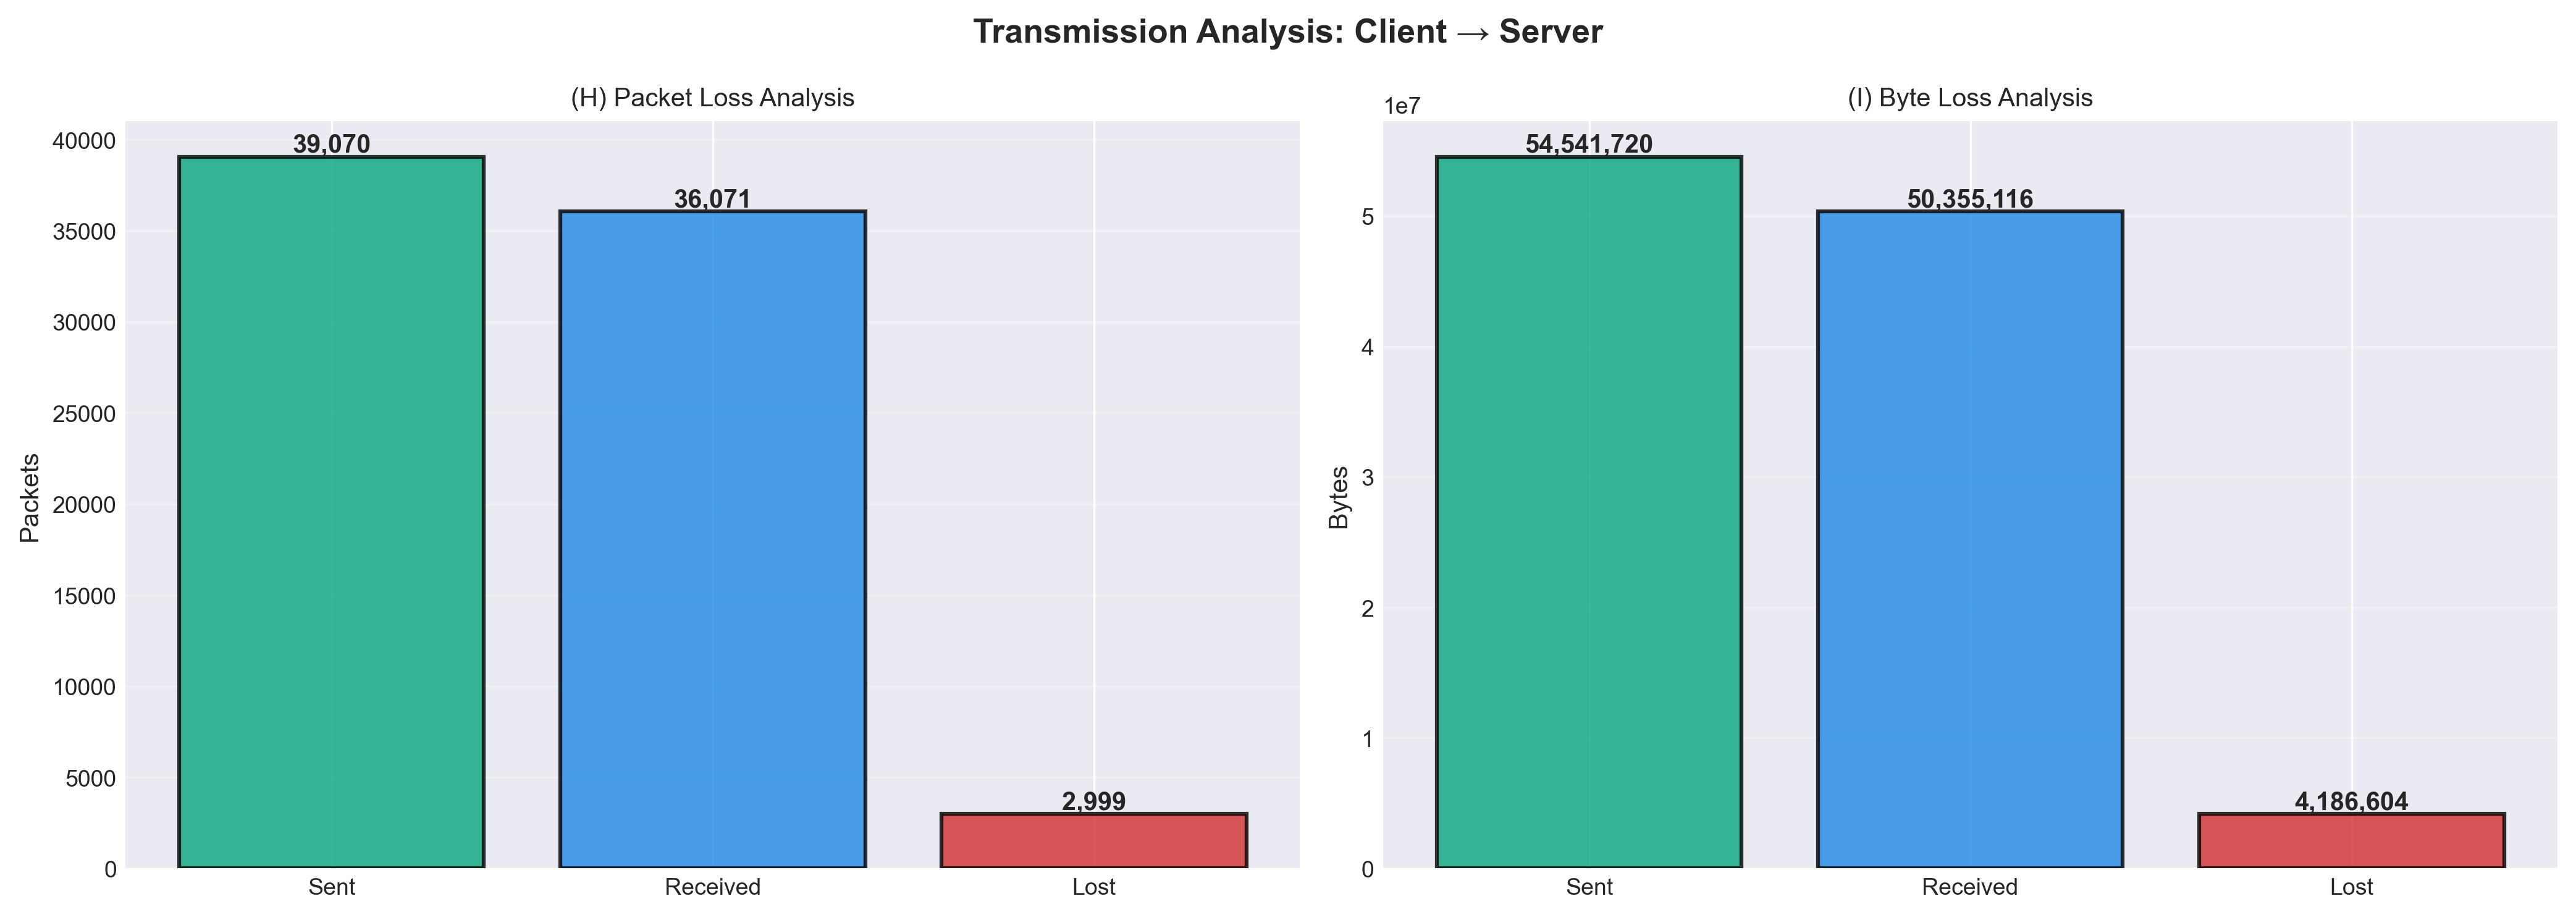

In [17]:

# Gráfico de Transmissão: Cliente → Servidor
if not df_client.empty and not df_server.empty and transmission_stats:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Transmission Analysis: Client → Server', fontsize=13, fontweight='bold')
    
    # (H) Packets: Sent vs Received
    ax = axes[0]
    categories = ['Sent', 'Received', 'Lost']
    values = [
        transmission_stats['client_packets_sent'],
        transmission_stats['server_packets_received'],
        transmission_stats['packets_lost']
    ]
    colors = ['#06A77D', '#1E88E5', '#D32F2F']
    
    bars = ax.bar(categories, values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(val):,}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_ylabel('Packets', fontsize=10)
    ax.set_title('(H) Packet Loss Analysis', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    # (I) Bytes: Sent vs Received
    ax = axes[1]
    categories = ['Sent', 'Received', 'Lost']
    bytes_values = [
        transmission_stats['client_bytes_sent_est'],
        transmission_stats['server_bytes_received_est'],
        transmission_stats['bytes_lost_est']
    ]
    
    bars = ax.bar(categories, bytes_values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    
    # Add value labels on bars (in bytes)
    for bar, val in zip(bars, bytes_values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(val):,}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    ax.set_ylabel('Bytes', fontsize=10)
    ax.set_title('(I) Byte Loss Analysis', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    
    # Save the transmission plot
    fname = OUTPUT_DIR / f"{base_name}_transmission_analysis.png"
    fig.savefig(fname, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {fname}")
    plt.show()


## Plotting Functions

In [18]:
def plot_client_metrics(df_client, metadata):
    """Plot RTT, Jitter, Inflight, Pacing Rate"""
    if df_client.empty:
        print("No client data to plot")
        return
    
    fig, axes = plt.subplots(4, 1, figsize=(12, 10))
    fig.suptitle('Client Metrics (ESP32 - UDP-Prague)', fontsize=13, fontweight='bold')
    
    # (A) RTT
    ax = axes[0]
    ax.plot(df_client['t_client_s'], df_client['rtt_ms'], color='#2E86AB', linewidth=1.5, label='RTT')
    ax.set_ylabel('RTT (ms)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title('(A) Round Trip Time', fontsize=10)
    
    # (B) Jitter
    ax = axes[1]
    ax.plot(df_client['t_client_s'], df_client['jitter_ms'], color='#A23B72', linewidth=1.5, label='Jitter')
    ax.set_ylabel('Jitter (ms)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title('(B) Jitter (Stability)', fontsize=10)
    
    # (C) Inflight
    ax = axes[2]
    ax.plot(df_client['t_client_s'], df_client['inflight'], color='#F18F01', linewidth=1.5, label='Inflight')
    ax.set_ylabel('Inflight (packets)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title('(C) In-Flight Packets (CC Behavior)', fontsize=10)
    
    # (D) Pacing Rate
    ax = axes[3]
    ax.plot(df_client['t_client_s'], df_client['pacing_rate_mbps'], color='#06A77D', linewidth=1.5, label='Pacing Rate')
    ax.set_ylabel('Pacing Rate (Mbps)', fontsize=10)
    ax.set_xlabel('Time (s)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title('(D) Pacing Rate (Adaptation)', fontsize=10)
    
    plt.tight_layout()
    return fig

def plot_server_metrics(df_server, metadata):
    """Plot RX Throughput, CE-mark Rate, Loss Rate"""
    if df_server.empty:
        print("No server data to plot")
        return
    
    fig, axes = plt.subplots(3, 1, figsize=(12, 9))
    fig.suptitle('Server Metrics (DualPI2 Gateway)', fontsize=13, fontweight='bold')
    
    # (E) RX Throughput
    ax = axes[0]
    ax.plot(df_server['time_sec'], df_server['rcvd_rate_bytes_s'], color='#1E88E5', linewidth=1.5, label='RX Throughput')
    ax.set_ylabel('Throughput (bytes/s)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title('(E) Received Throughput', fontsize=10)
    
    # (F) CE-mark Rate
    ax = axes[1]
    ax.plot(df_server['time_sec'], df_server['ce_rate_percent'], color='#D32F2F', linewidth=1.5, label='CE-mark Rate')
    ax.set_ylabel('CE-mark Rate (%)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title('(F) CE-Mark Rate (L4S Signal)', fontsize=10)
    
    # (G) Loss Rate
    ax = axes[2]
    ax.plot(df_server['time_sec'], df_server['loss_rate_percent'], color='#FF6F00', linewidth=1.5, label='Loss Rate')
    ax.set_ylabel('Loss Rate (%)', fontsize=10)
    ax.set_xlabel('Time (s)', fontsize=10)
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_title('(G) Packet Loss', fontsize=10)
    
    plt.tight_layout()
    return fig

def plot_cdf_rtt(df_client):
    """Plot CDF of RTT"""
    if df_client.empty:
        return
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    rtt_sorted = np.sort(df_client['rtt_ms'].dropna())
    cdf = np.arange(1, len(rtt_sorted) + 1) / len(rtt_sorted)
    
    ax.plot(rtt_sorted, cdf * 100, color='#2E86AB', linewidth=2, label='RTT CDF')
    ax.set_xlabel('RTT (ms)', fontsize=11)
    ax.set_ylabel('Probability (%)', fontsize=11)
    ax.set_title('(I) CDF of RTT (Client)', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    
    plt.tight_layout()
    return fig

print("✓ Plotting functions defined")

✓ Plotting functions defined


## Generate and Save Plots

Output name: prague_academic_high_load_node1_ccprague_qdiscdualpi2_ecn1
✓ Saved: /Users/juscelioreis/Documents/code/master-l4s-iot/esp32-udp-prague/experiments/t06-ecn-sender-ect1-prague-dualpi2-ecn2/prague_academic_high_load_node1_ccprague_qdiscdualpi2_ecn1_client_metrics.png


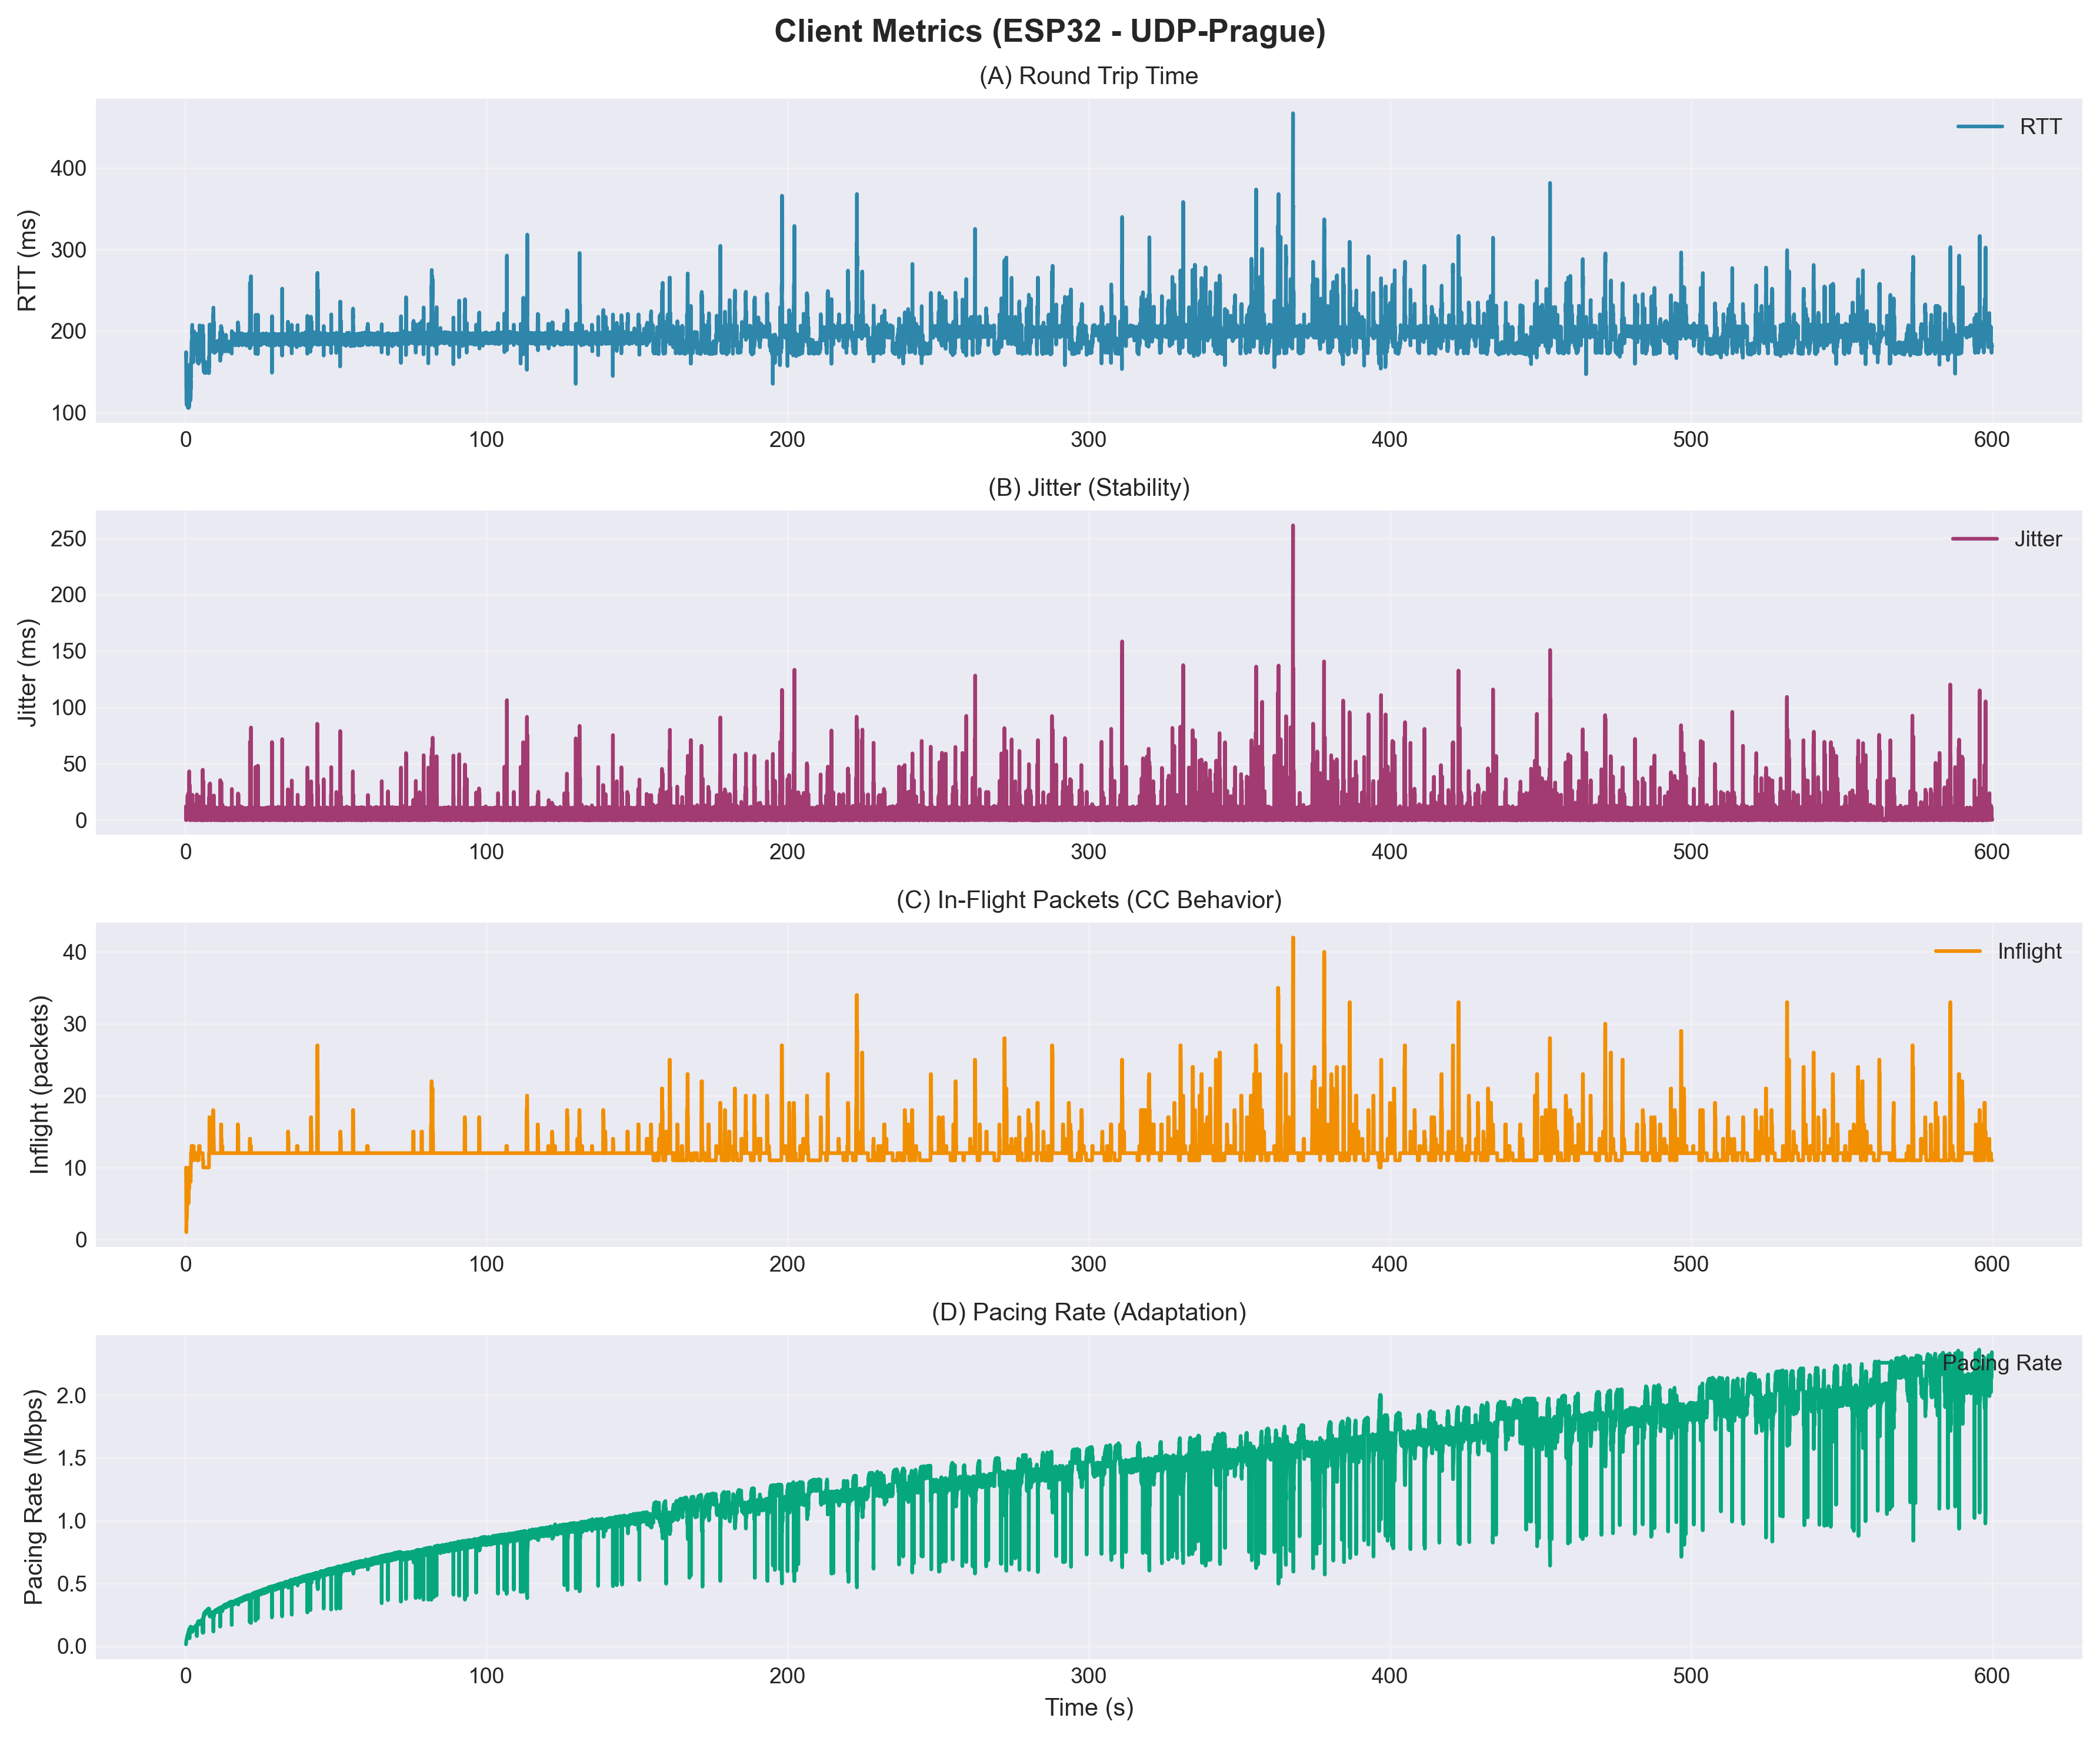

✓ Saved: /Users/juscelioreis/Documents/code/master-l4s-iot/esp32-udp-prague/experiments/t06-ecn-sender-ect1-prague-dualpi2-ecn2/prague_academic_high_load_node1_ccprague_qdiscdualpi2_ecn1_server_metrics.png


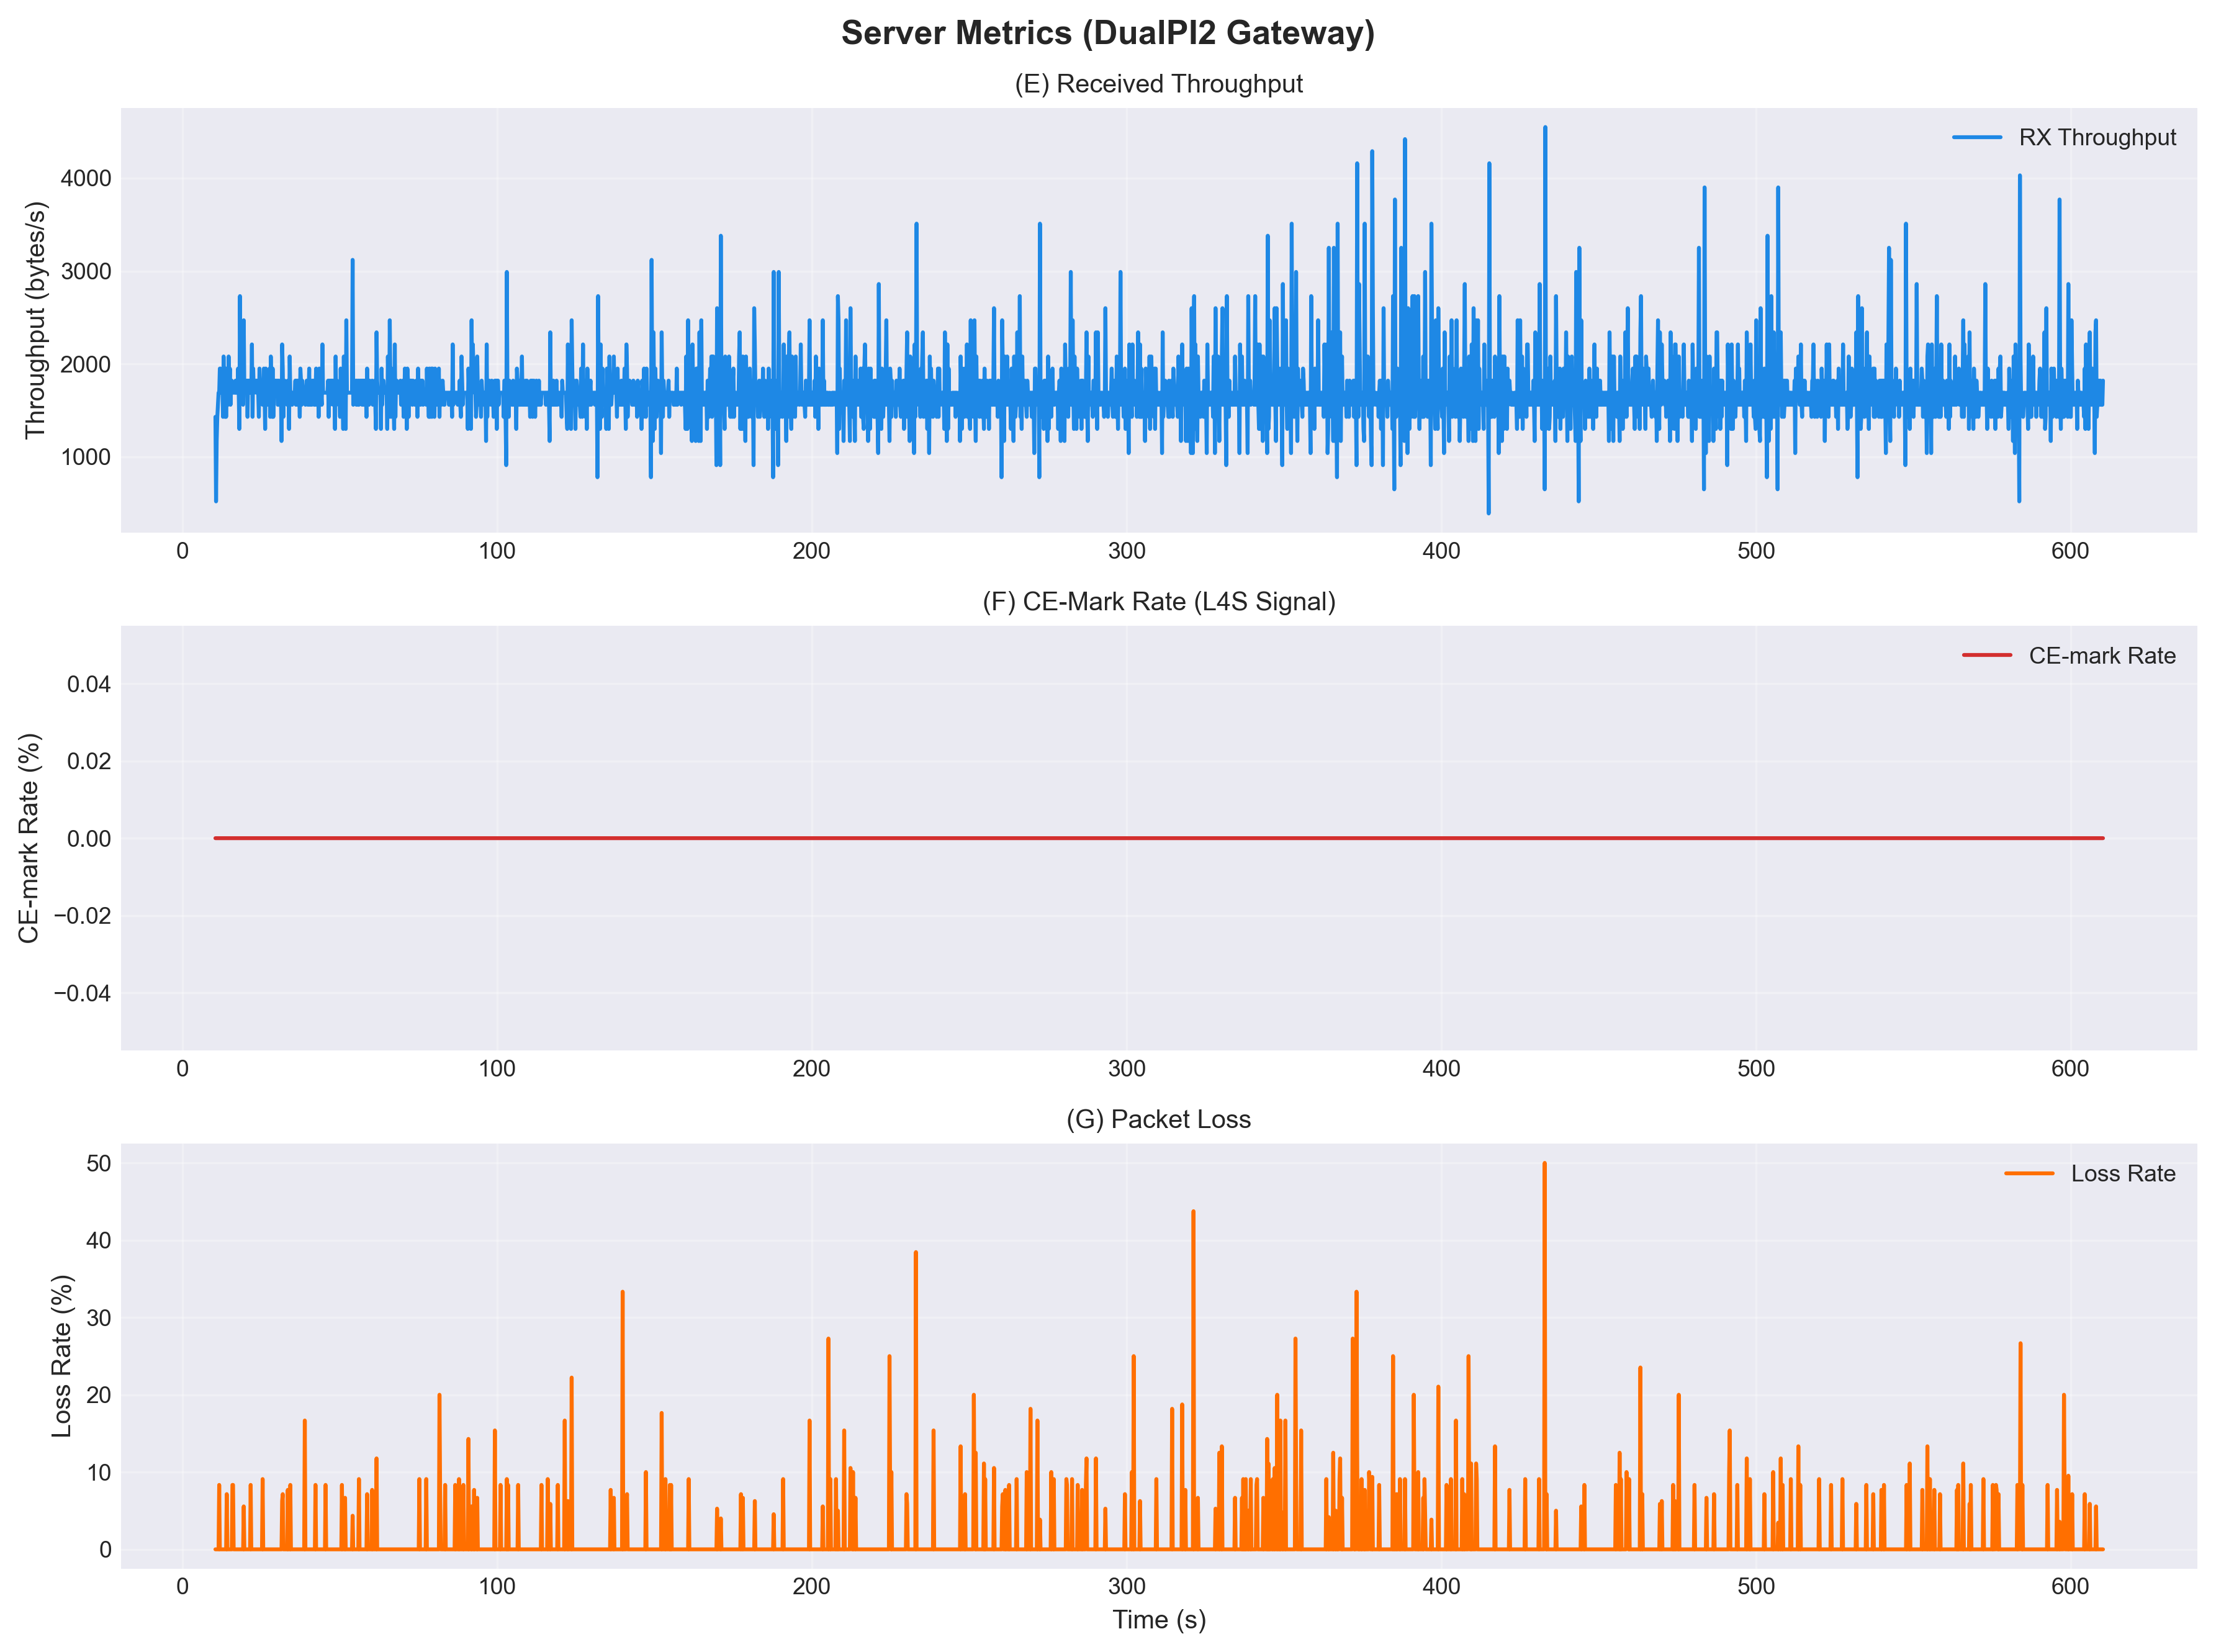

✓ Saved: /Users/juscelioreis/Documents/code/master-l4s-iot/esp32-udp-prague/experiments/t06-ecn-sender-ect1-prague-dualpi2-ecn2/prague_academic_high_load_node1_ccprague_qdiscdualpi2_ecn1_rtt_cdf.png


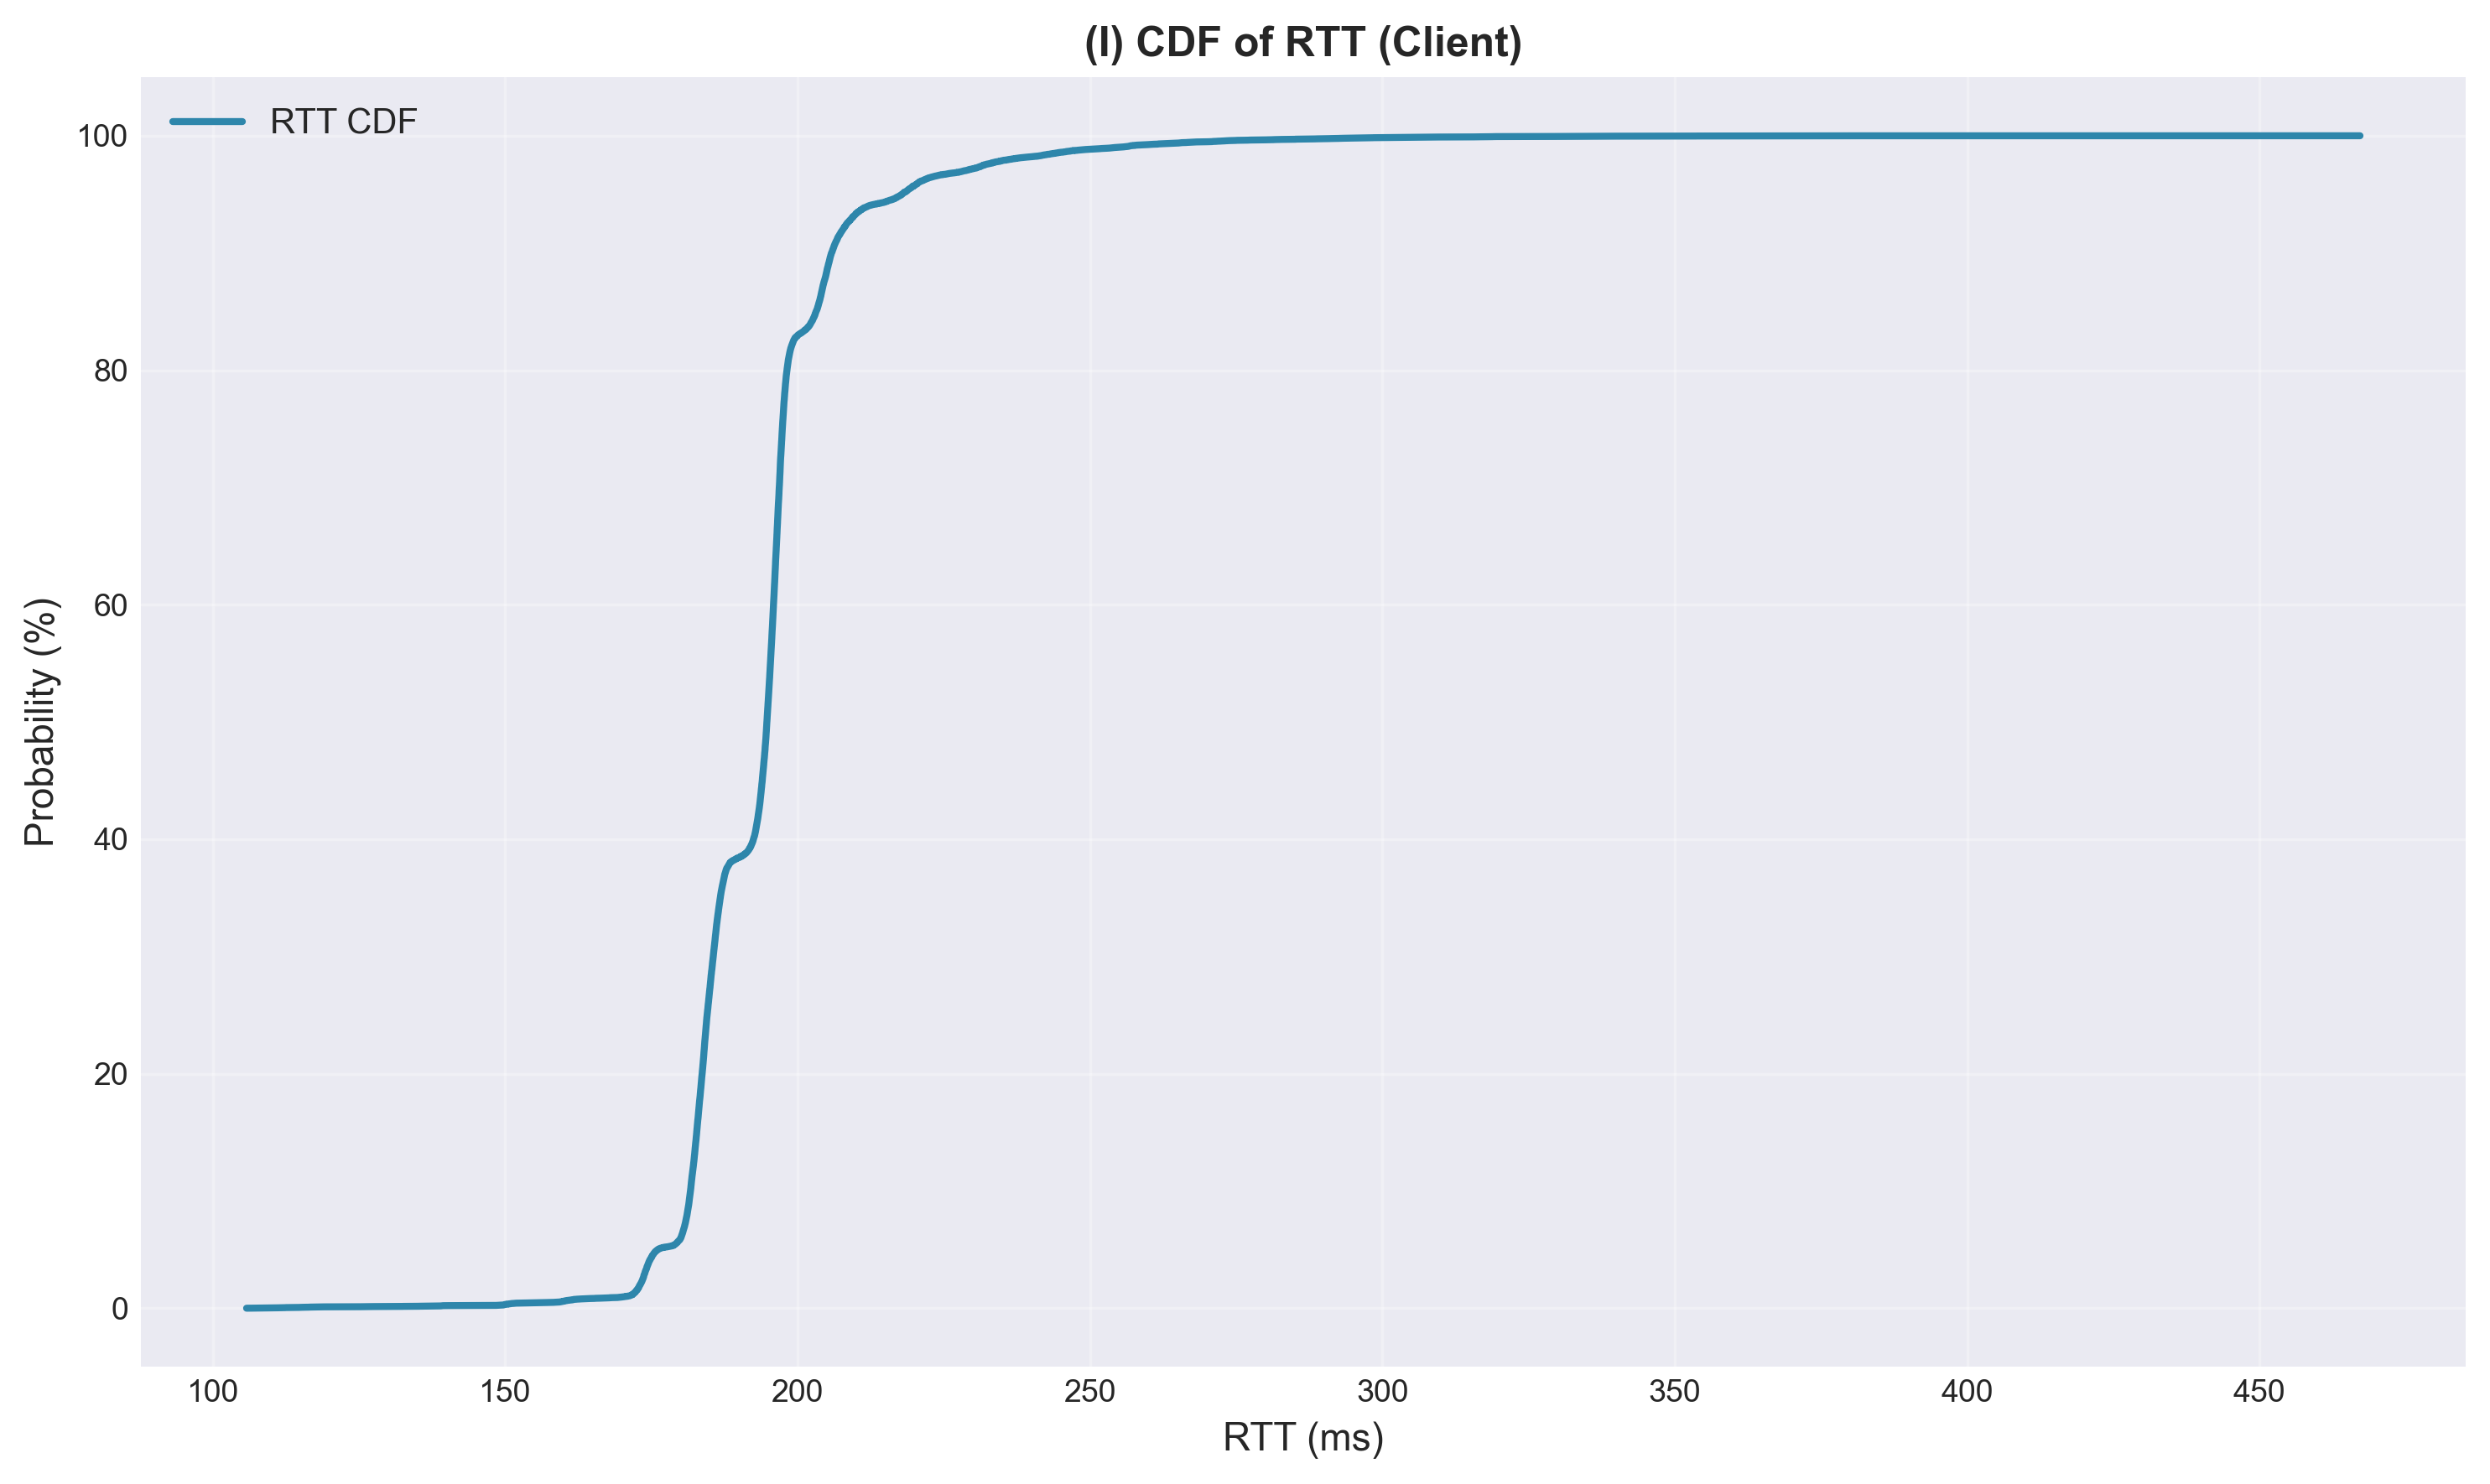

In [19]:
# Generate output filename from metadata
def build_output_name(metadata):
    parts = ['prague_academic']
    
    scenario = metadata.get('Test Scenario', '').lower().replace(' ', '_')
    if scenario:
        parts.append(scenario)
    
    node = metadata.get('IoT Node ID', '')
    if node:
        digits = re.findall(r'\d+', node)
        if digits:
            parts.append(f'node{digits[0]}')
    
    cc = metadata.get('Gateway CC Algorithm', '').lower().replace(' ', '_')
    if cc:
        parts.append(f'cc{cc}')
    
    qdisc = metadata.get('Gateway Qdisc', '').lower().replace(' ', '_')
    if qdisc:
        parts.append(f'qdisc{qdisc}')
    
    ecn = metadata.get('ECN', '')
    if ecn:
        parts.append(f'ecn{ecn}')

    return '_'.join(parts)

base_name = build_output_name(metadata)
print(f"Output name: {base_name}")

# Plot and save client metrics
if not df_client.empty:
    fig = plot_client_metrics(df_client, metadata)
    if fig:
        fname = OUTPUT_DIR / f"{base_name}_client_metrics.png"
        fig.savefig(fname, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {fname}")
        plt.show()

# Plot and save server metrics
if not df_server.empty:
    fig = plot_server_metrics(df_server, metadata)
    if fig:
        fname = OUTPUT_DIR / f"{base_name}_server_metrics.png"
        fig.savefig(fname, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {fname}")
        plt.show()

# Plot and save CDF of RTT
if not df_client.empty:
    fig = plot_cdf_rtt(df_client)
    if fig:
        fname = OUTPUT_DIR / f"{base_name}_rtt_cdf.png"
        fig.savefig(fname, dpi=300, bbox_inches='tight')
        print(f"✓ Saved: {fname}")
        plt.show()

## Export CSV

In [20]:

# Export raw data
if not df_client.empty:
    fname_csv = OUTPUT_DIR / f"{base_name}_client.csv"
    df_client.to_csv(fname_csv, index=False)
    print(f"✓ Saved: {fname_csv}")

if not df_server.empty:
    fname_csv = OUTPUT_DIR / f"{base_name}_server.csv"
    df_server.to_csv(fname_csv, index=False)
    print(f"✓ Saved: {fname_csv}")

# Summary statistics with confidence intervals
if not df_client.empty or not df_server.empty:
    from scipy.stats import t as t_dist

    def _ci(data, confidence=0.95):
        n = len(data)
        if n < 2:
            return np.nan, np.nan
        se = np.std(data, ddof=1) / np.sqrt(n)
        h = se * t_dist.ppf((1 + confidence) / 2, n - 1)
        return np.mean(data) - h, np.mean(data) + h

    summary = {}
    if not df_client.empty:
        # Steady-state (exclude first 10%)
        n_warmup = int(len(df_client) * 0.10)
        df_ss = df_client.iloc[n_warmup:]

        rtt_ci = _ci(df_ss['rtt_ms'])
        jit_ci = _ci(df_ss['jitter_ms'])

        summary.update({
            'client_samples': len(df_client),
            'steadystate_samples': len(df_ss),
            'client_duration_s': df_client['t_client_s'].max() - df_client['t_client_s'].min(),
            'rtt_mean_ms': df_ss['rtt_ms'].mean(),
            'rtt_ci_lower_ms': rtt_ci[0],
            'rtt_ci_upper_ms': rtt_ci[1],
            'rtt_p50_ms': df_ss['rtt_ms'].median(),
            'rtt_p95_ms': df_ss['rtt_ms'].quantile(0.95),
            'rtt_p99_ms': df_ss['rtt_ms'].quantile(0.99),
            'rtt_cv_pct': (df_ss['rtt_ms'].std() / df_ss['rtt_ms'].mean() * 100) if df_ss['rtt_ms'].mean() != 0 else np.nan,
            'jitter_mean_ms': df_ss['jitter_ms'].mean(),
            'jitter_ci_lower_ms': jit_ci[0],
            'jitter_ci_upper_ms': jit_ci[1],
            'inflight_mean': df_ss['inflight'].mean(),
            'pacing_rate_mean_mbps': df_ss['pacing_rate_mbps'].mean(),
        })

    if not df_server.empty:
        summary.update({
            'server_samples': len(df_server),
            'server_duration_s': df_server['time_sec'].max() - df_server['time_sec'].min(),
            'rx_throughput_mean_bytes_s': df_server['rcvd_rate_bytes_s'].mean(),
            'rx_throughput_min_bytes_s': df_server['rcvd_rate_bytes_s'].min(),
            'rx_throughput_max_bytes_s': df_server['rcvd_rate_bytes_s'].max(),
            'ce_mark_rate_mean_percent': df_server['ce_rate_percent'].mean(),
            'loss_rate_mean_percent': df_server['loss_rate_percent'].mean(),
        })

    # Add transmission analysis stats
    if transmission_stats:
        summary.update(transmission_stats)

    summary_df = pd.DataFrame([summary])
    fname_summary = OUTPUT_DIR / f"{base_name}_summary.csv"
    summary_df.to_csv(fname_summary, index=False)
    print(f"✓ Saved: {fname_summary}")
    print(f"\n📊 Summary Statistics:")
    print(summary_df.T)


✓ Saved: /Users/juscelioreis/Documents/code/master-l4s-iot/esp32-udp-prague/experiments/t06-ecn-sender-ect1-prague-dualpi2-ecn2/prague_academic_high_load_node1_ccprague_qdiscdualpi2_ecn1_client.csv
✓ Saved: /Users/juscelioreis/Documents/code/master-l4s-iot/esp32-udp-prague/experiments/t06-ecn-sender-ect1-prague-dualpi2-ecn2/prague_academic_high_load_node1_ccprague_qdiscdualpi2_ecn1_server.csv
✓ Saved: /Users/juscelioreis/Documents/code/master-l4s-iot/esp32-udp-prague/experiments/t06-ecn-sender-ect1-prague-dualpi2-ecn2/prague_academic_high_load_node1_ccprague_qdiscdualpi2_ecn1_summary.csv

📊 Summary Statistics:
                                       0
client_samples              3.696600e+04
steadystate_samples         3.327000e+04
client_duration_s           5.998230e+02
rtt_mean_ms                 1.948860e+02
rtt_ci_lower_ms             1.947247e+02
rtt_ci_upper_ms             1.950472e+02
rtt_p50_ms                  1.951715e+02
rtt_p95_ms                  2.189781e+02
rtt_p99_ms   

## 📐 Statistical Rigor (Academic)

📐 STATISTICAL RIGOR REPORT

Total samples: 36,966
Warmup excluded: first 3,696 samples (10%)
Steady-state samples: 33,270

Metric                          Mean   95% CI Lower   95% CI Upper     CV (%)    Normality
-------------------------------------------------------------------------------------
RTT (ms)                     194.886 [      194.725,       195.047]       7.7%  p=4.09e-69
Jitter (ms)                    5.464 [        5.368,         5.560]     163.2%  p=1.12e-74
Inflight (pkts)               12.396 [       12.370,        12.421]      19.1%  p=7.94e-91
Pacing Rate (Mbps)             1.451 [        1.446,         1.455]      29.8%  p=2.63e-34

✓ Saved: /Users/juscelioreis/Documents/code/master-l4s-iot/esp32-udp-prague/experiments/t06-ecn-sender-ect1-prague-dualpi2-ecn2/prague_academic_high_load_node1_ccprague_qdiscdualpi2_ecn1_boxplots_steadystate.png


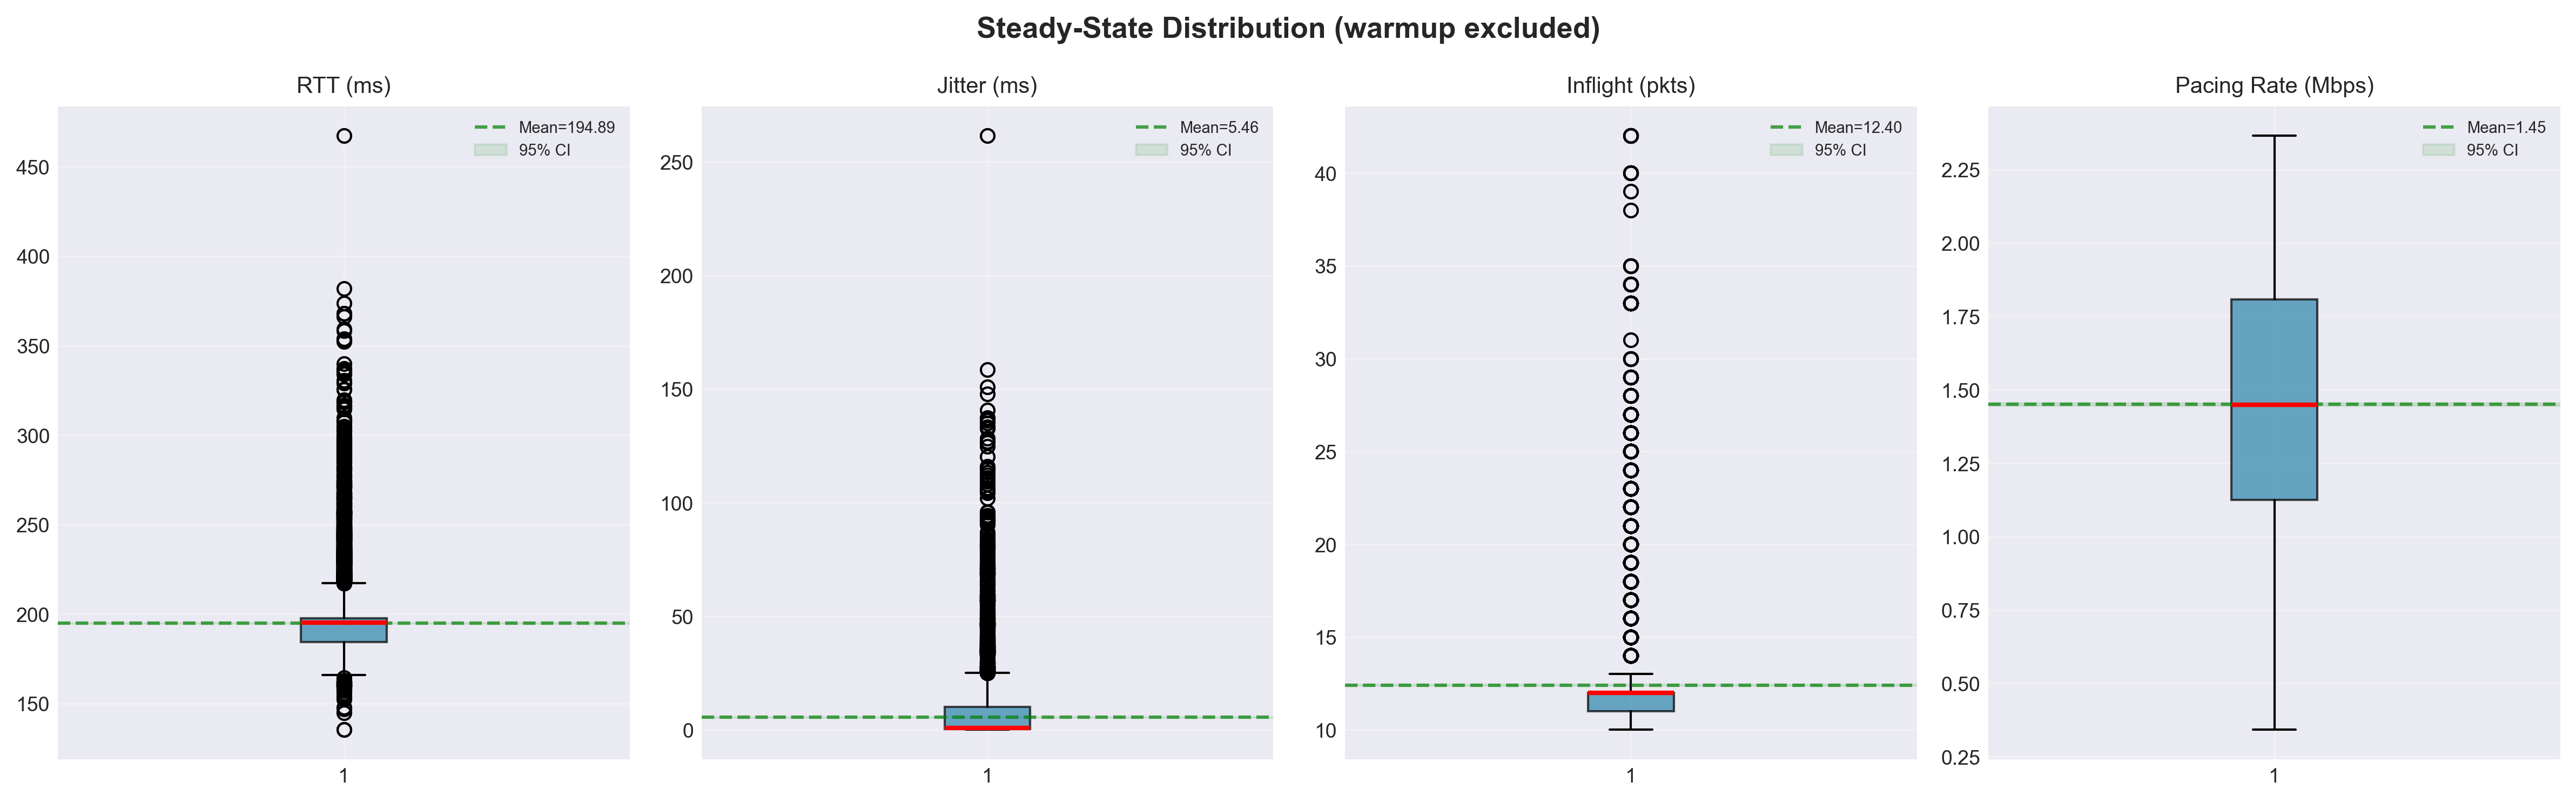

✓ Saved: /Users/juscelioreis/Documents/code/master-l4s-iot/esp32-udp-prague/experiments/t06-ecn-sender-ect1-prague-dualpi2-ecn2/prague_academic_high_load_node1_ccprague_qdiscdualpi2_ecn1_rtt_cdf_annotated.png


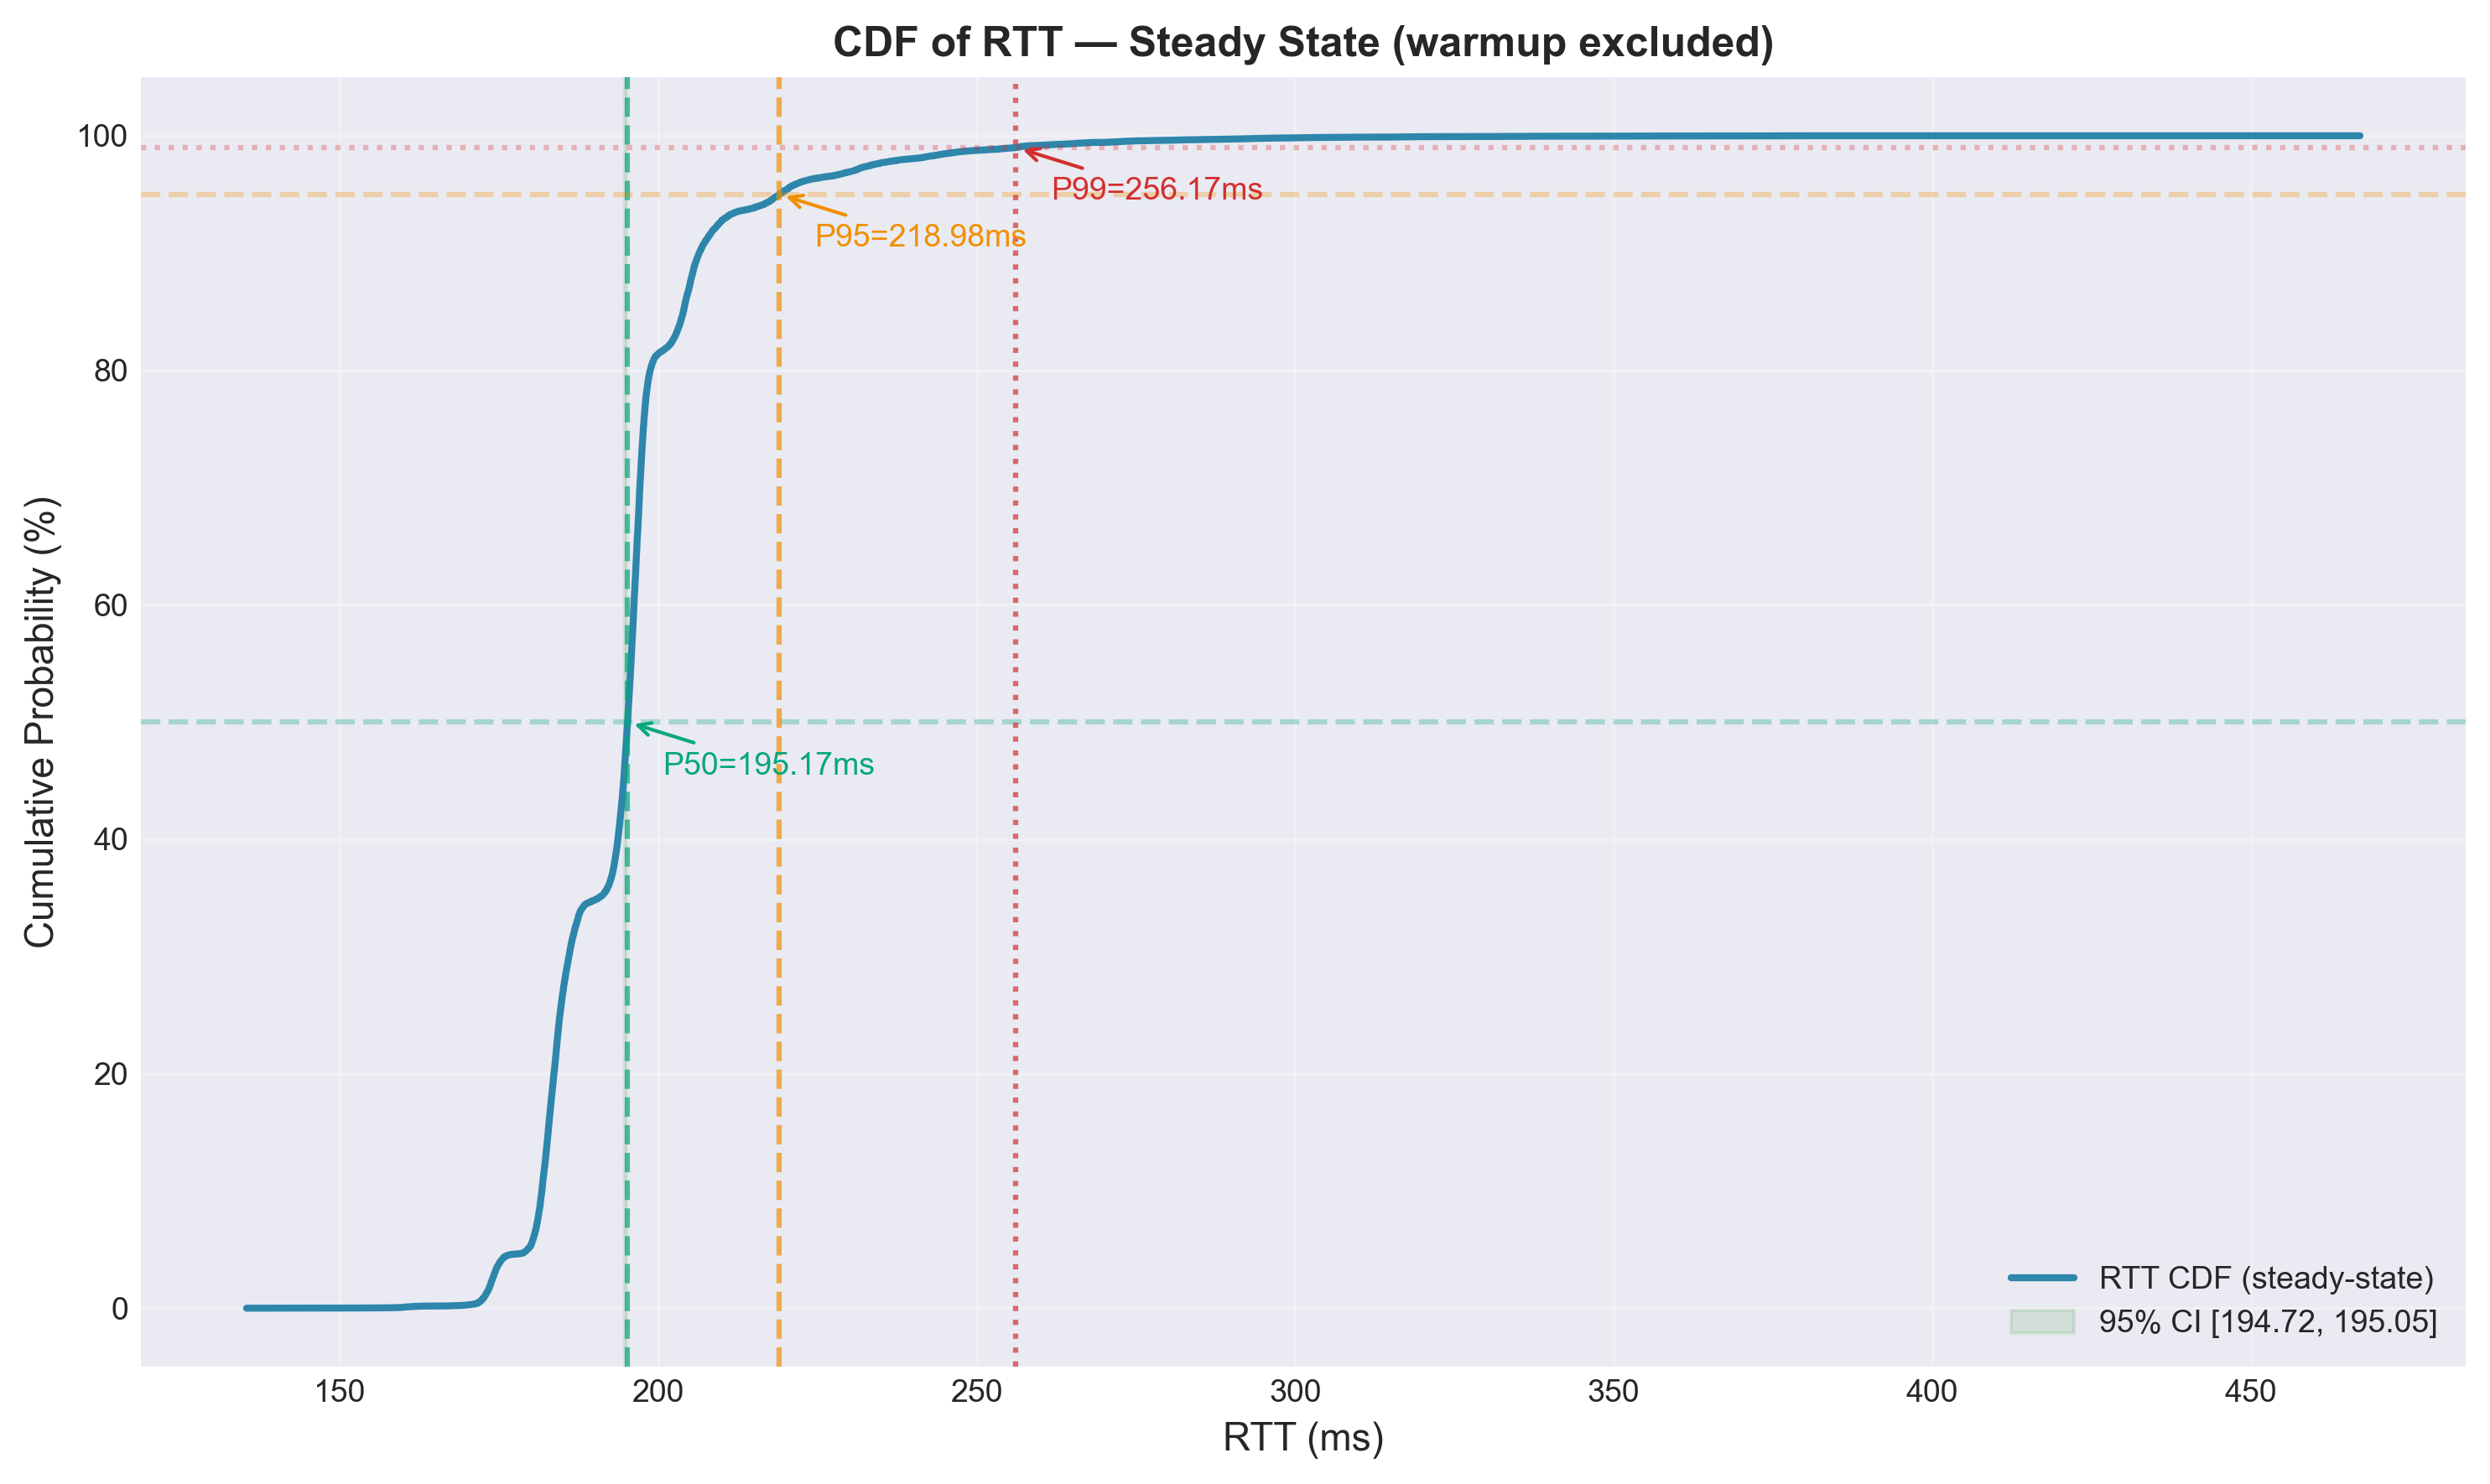


📝 SUMMARY FOR DISSERTATION

Test: t06-ecn-sender-ect1-prague-dualpi2-ecn2
Steady-state samples: 33,270 (90% of 36,966)
RTT: 194.886 ms [95% CI: 194.725, 195.047], CV=7.7%
Jitter: 5.464 ms [95% CI: 5.368, 5.560], CV=163.2%
RTT P50=195.171 ms, P95=218.978 ms, P99=256.167 ms


In [21]:

# ===== STATISTICAL RIGOR FOR ACADEMIC PUBLICATION =====
# Implements: 95% CI, Shapiro-Wilk normality, CV, box plots,
# annotated CDF, steady-state segmentation.

from scipy.stats import shapiro, t as t_dist

def compute_ci(data, confidence=0.95):
    """Compute confidence interval using t-distribution."""
    n = len(data)
    if n < 2:
        return np.nan, np.nan, np.nan
    mean = np.mean(data)
    se = np.std(data, ddof=1) / np.sqrt(n)
    h = se * t_dist.ppf((1 + confidence) / 2, n - 1)
    return mean, mean - h, mean + h

def compute_cv(data):
    """Coefficient of variation (%)."""
    mean = np.mean(data)
    if mean == 0:
        return np.nan
    return (np.std(data, ddof=1) / mean) * 100

if not df_client.empty:
    # --- Steady-state segmentation ---
    warmup_frac = 0.10  # exclude first 10%
    n_total = len(df_client)
    n_warmup = int(n_total * warmup_frac)
    df_ss = df_client.iloc[n_warmup:].copy()

    print("="*70)
    print("📐 STATISTICAL RIGOR REPORT")
    print("="*70)
    print(f"\nTotal samples: {n_total:,}")
    print(f"Warmup excluded: first {n_warmup:,} samples ({warmup_frac*100:.0f}%)")
    print(f"Steady-state samples: {len(df_ss):,}")

    # --- 95% Confidence Intervals ---
    metrics = {
        'RTT (ms)': df_ss['rtt_ms'].values,
        'Jitter (ms)': df_ss['jitter_ms'].values,
        'Inflight (pkts)': df_ss['inflight'].values,
        'Pacing Rate (Mbps)': df_ss['pacing_rate_mbps'].values,
    }

    print(f"\n{'Metric':<25} {'Mean':>10} {'95% CI Lower':>14} {'95% CI Upper':>14} {'CV (%)':>10} {'Normality':>12}")
    print("-"*85)

    stat_results = {}
    for name, data in metrics.items():
        mean, ci_lo, ci_hi = compute_ci(data)
        cv = compute_cv(data)

        # Shapiro-Wilk (sample up to 5000 for performance)
        sample = data[:5000] if len(data) > 5000 else data
        if len(sample) >= 20:
            sw_stat, sw_p = shapiro(sample)
            normality = f"p={sw_p:.2e}"
        else:
            sw_stat, sw_p = np.nan, np.nan
            normality = "N/A (n<20)"

        print(f"{name:<25} {mean:>10.3f} [{ci_lo:>13.3f}, {ci_hi:>13.3f}] {cv:>9.1f}%  {normality}")

        stat_results[name] = {
            'mean': mean, 'ci_lower': ci_lo, 'ci_upper': ci_hi,
            'cv': cv, 'shapiro_p': sw_p, 'n': len(data),
        }

    # --- Box Plots (steady-state) ---
    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    fig.suptitle('Steady-State Distribution (warmup excluded)', fontsize=13, fontweight='bold')

    for ax, (name, data) in zip(axes, metrics.items()):
        bp = ax.boxplot(data, patch_artist=True,
                        boxprops=dict(facecolor='#2E86AB', alpha=0.7),
                        medianprops=dict(color='red', linewidth=2))
        mean_val, ci_lo, ci_hi = compute_ci(data)
        ax.axhline(mean_val, color='green', linestyle='--', alpha=0.7, label=f'Mean={mean_val:.2f}')
        ax.axhspan(ci_lo, ci_hi, color='green', alpha=0.1, label='95% CI')
        ax.set_title(name, fontsize=10)
        ax.legend(fontsize=7, loc='upper right')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fname = OUTPUT_DIR / f"{base_name}_boxplots_steadystate.png"
    fig.savefig(fname, dpi=300, bbox_inches='tight')
    print(f"\n✓ Saved: {fname}")
    plt.show()

    # --- Annotated CDF ---
    fig, ax = plt.subplots(figsize=(10, 6))
    rtt_ss = np.sort(df_ss['rtt_ms'].dropna().values)
    cdf = np.arange(1, len(rtt_ss) + 1) / len(rtt_ss)

    ax.plot(rtt_ss, cdf * 100, color='#2E86AB', linewidth=2, label='RTT CDF (steady-state)')

    # Annotate percentiles
    for pct, color, style in [(50, '#06A77D', '--'), (95, '#F18F01', '--'), (99, '#D32F2F', ':')]:
        val = np.percentile(rtt_ss, pct)
        ax.axvline(val, color=color, linestyle=style, alpha=0.7)
        ax.axhline(pct, color=color, linestyle=style, alpha=0.3)
        ax.annotate(f'P{pct}={val:.2f}ms', xy=(val, pct), fontsize=9,
                    xytext=(10, -15), textcoords='offset points',
                    arrowprops=dict(arrowstyle='->', color=color), color=color)

    # Annotate mean with CI
    rtt_mean, rtt_ci_lo, rtt_ci_hi = compute_ci(rtt_ss)
    ax.axvspan(rtt_ci_lo, rtt_ci_hi, color='green', alpha=0.1, label=f'95% CI [{rtt_ci_lo:.2f}, {rtt_ci_hi:.2f}]')

    ax.set_xlabel('RTT (ms)', fontsize=11)
    ax.set_ylabel('Cumulative Probability (%)', fontsize=11)
    ax.set_title('CDF of RTT — Steady State (warmup excluded)', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    fname = OUTPUT_DIR / f"{base_name}_rtt_cdf_annotated.png"
    fig.savefig(fname, dpi=300, bbox_inches='tight')
    print(f"✓ Saved: {fname}")
    plt.show()

    # --- Summary for dissertation ---
    print("\n" + "="*70)
    print("📝 SUMMARY FOR DISSERTATION")
    print("="*70)
    r = stat_results.get('RTT (ms)', {})
    j = stat_results.get('Jitter (ms)', {})
    print(f"\nTest: {TESTCASE}")
    print(f"Steady-state samples: {len(df_ss):,} ({(1-warmup_frac)*100:.0f}% of {n_total:,})")
    if r:
        print(f"RTT: {r['mean']:.3f} ms [95% CI: {r['ci_lower']:.3f}, {r['ci_upper']:.3f}], CV={r['cv']:.1f}%")
    if j:
        print(f"Jitter: {j['mean']:.3f} ms [95% CI: {j['ci_lower']:.3f}, {j['ci_upper']:.3f}], CV={j['cv']:.1f}%")
    print(f"RTT P50={df_ss['rtt_ms'].median():.3f} ms, P95={df_ss['rtt_ms'].quantile(0.95):.3f} ms, P99={df_ss['rtt_ms'].quantile(0.99):.3f} ms")

    if not df_server.empty:
        coverage = transmission_stats.get('server_coverage_pct', 0)
        if coverage < 90:
            print(f"\n⚠️  Server coverage: {coverage:.1f}% — server metrics may not be representative")
else:
    print("⚠️  No client data available for statistical analysis")
